# sklearn model with tensorflow keras tuner

In [ ]:
# ! python -m pip install --no-index --find-links=/kaggle/usr/lib/pip_install_permanent/my_packages -r /kaggle/usr/lib/pip_install_permanent/requirements.txt

In [ ]:
# import os
# os.environ['PACKAGE_DIR'] = '/kaggle/usr/lib/pip_install_permanent'

In [1]:
import sklearn
print(sklearn.__version__)

1.2.2


In [2]:
from helper_func import *
# # import helper_functions as hf
# import sys
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# import string
# from spellchecker import SpellChecker
# from textblob import TextBlob
# from multiprocessing import Pool
# from tqdm import tqdm
# import numpy as np
# import pandas as pd
# # Preprocessing
# from nltk.tokenize import word_tokenize, sent_tokenize
# import operator
# from spellchecker import SpellChecker
# from tqdm import tqdm  # Import tqdm
# import re
# import inflect
# from wordsegment import load, segment
# from nltk.corpus import words
# word_list = set(words.words())
# from spellchecker import SpellChecker

# from tqdm.contrib.concurrent import process_map  # If this import fails, you might need to update tqdm

# import multiprocessing
 
# # Import Packages
# # import shutup; shutup.please()
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import tensorflow as tf
# import keras_tuner as kt
# import seaborn as sns

# from nltk.corpus import stopwords, wordnet
# from nltk.tokenize import word_tokenize, sent_tokenize
# from nltk import pos_tag, ne_chunk
# from textblob import TextBlob

# from textstat import flesch_reading_ease, smog_index

# import spacy
# from collections import Counter
# from gensim import corpora, models
# import pyLDAvis.gensim as gen
# import pyLDAvis
# import re

# # Machine Learning & Data Preprocessing

# from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from sklearn.model_selection import train_test_split
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# # Deep Learning

# from tensorflow.keras import layers
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences

# # Gensim
# # from gensim.models import Word2Vec, KeyedVectors
# import pandas as pd
# # Progress bar
# from tqdm import tqdm

# # Keras Tuner
# from keras_tuner.tuners import RandomSearch

# # # Setting logging levels and environment variables
# # tf.get_logger().setLevel(logging.ERROR)
# # os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# from textstat import flesch_reading_ease

# # from helper_functions import *
# import nltk
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# import string
# from spellchecker import SpellChecker
# from textblob import TextBlob
# from multiprocessing import Pool
# from tqdm import tqdm
# import numpy as np
# import pandas as pd
# # Preprocessing
# from nltk.tokenize import word_tokenize, sent_tokenize
# import operator
# from spellchecker import SpellChecker
# from tqdm import tqdm  # Import tqdm
# import re
# import inflect
# from wordsegment import load, segment
# from nltk.corpus import words
# word_list = set(words.words())
# print('Packages Instaled......')
import sklearn
print(sklearn.__version__)

/home/jack/envs/scoring/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1.2.2


[nltk_data] Downloading package punkt to /home/jack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/jack/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
import sklearn
print(sklearn.__version__)

1.2.2


In [4]:
import pandas as pd

deberta_train = pd.read_csv('/home/jack/github/kaggle/scoring/deberta_train_predictions.csv')
deberta_val = pd.read_csv('/home/jack/github/kaggle/scoring/deberta_val_predictions.csv')

In [5]:
deberta_full = pd.concat([deberta_train, deberta_val])
deberta_full.head()

,essay_id,clean_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5
0,000fe60,i am a scientist at nasa that is discussing th...,3,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375
1,001ab80,people always wish they had the same technolog...,4,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815
2,002ba53,dear state senator this is a letter to argue i...,3,0.052828,0.680586,0.248129,0.016296,0.001250,0.000911
3,0033037,the posibilty of a face reconizing computer wo...,2,0.110127,0.875541,0.012530,0.000799,0.000427,0.000577
4,0033bf4,what is the seagoing cowboys progam it was to ...,3,0.004650,0.469768,0.515730,0.009045,0.000419,0.000389


In [6]:
xlnet = pd.read_csv('/home/jack/github/kaggle/scoring/xlnet_hash.csv')
xlnet.drop(columns=['score', 'labels', 'clean_text'], inplace=True)
xlnet.head()

,essay_id,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,...,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
0,000fe60,0.117232,0.165677,0.152534,0.296718,0.160982,0.106857,0.071429,0.023810,0.023810,...,0.000000,0.119048,0.000000,0.000000,0.000000,0.023810,0.190476,0.071429,0.000000,0.02381
1,001ab80,0.122395,0.173042,0.157923,0.290913,0.147577,0.108148,0.014565,0.000000,0.058259,...,0.029130,0.043694,0.014565,0.014565,0.000000,0.014565,0.262167,0.014565,0.000000,0.00000
2,002ba53,0.116014,0.175220,0.155120,0.296571,0.148355,0.108720,0.047637,0.000000,0.079395,...,0.000000,0.031758,0.000000,0.000000,0.000000,0.000000,0.381096,0.000000,0.031758,0.00000
3,0033037,0.115277,0.171964,0.149637,0.293035,0.157809,0.112278,0.000000,0.000000,0.000000,...,0.000000,0.039073,0.000000,0.000000,0.000000,0.000000,0.195366,0.000000,0.000000,0.00000
4,0033bf4,0.117789,0.165247,0.158900,0.288238,0.159338,0.110489,0.000000,0.019364,0.038727,...,0.019364,0.019364,0.000000,0.019364,0.019364,0.000000,0.096819,0.193637,0.000000,0.00000


In [7]:
deberta_full = deberta_full.merge(xlnet, on='essay_id', how='left')
deberta_full.head()

,essay_id,clean_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,...,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
0,000fe60,i am a scientist at nasa that is discussing th...,3,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375,0.117232,...,0.000000,0.119048,0.000000,0.000000,0.000000,0.023810,0.190476,0.071429,0.000000,0.02381
1,001ab80,people always wish they had the same technolog...,4,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815,0.122395,...,0.029130,0.043694,0.014565,0.014565,0.000000,0.014565,0.262167,0.014565,0.000000,0.00000
2,002ba53,dear state senator this is a letter to argue i...,3,0.052828,0.680586,0.248129,0.016296,0.001250,0.000911,0.116014,...,0.000000,0.031758,0.000000,0.000000,0.000000,0.000000,0.381096,0.000000,0.031758,0.00000
3,0033037,the posibilty of a face reconizing computer wo...,2,0.110127,0.875541,0.012530,0.000799,0.000427,0.000577,0.115277,...,0.000000,0.039073,0.000000,0.000000,0.000000,0.000000,0.195366,0.000000,0.000000,0.00000
4,0033bf4,what is the seagoing cowboys progam it was to ...,3,0.004650,0.469768,0.515730,0.009045,0.000419,0.000389,0.117789,...,0.019364,0.019364,0.000000,0.019364,0.019364,0.000000,0.096819,0.193637,0.000000,0.00000


In [8]:
deberta_full.tail()

,essay_id,clean_text,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,...,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
17302,ffb732c,in the story the challenge of exploring venus ...,3,0.019354,0.880652,0.097258,0.002129,0.000283,0.000324,0.117180,...,0.000000,0.070809,0.000000,0.000000,0.000000,0.023603,0.141618,0.000000,0.023603,0.000000
17303,ffc11a8,you should join the seagoing cowboys because y...,3,0.014421,0.824093,0.157574,0.003208,0.000317,0.000387,0.118373,...,0.077806,0.038903,0.019451,0.019451,0.019451,0.019451,0.213966,0.077806,0.019451,0.000000
17304,ffcb061,becoming a seagoing cowboy is a once in a life...,3,0.011004,0.576294,0.398395,0.013302,0.000534,0.000472,0.118490,...,0.016988,0.118918,0.050965,0.016988,0.016988,0.000000,0.135906,0.033976,0.033976,0.033976
17305,ffd378d,the story the challenge of exploing venus is a...,2,0.150013,0.835257,0.012670,0.000888,0.000525,0.000646,0.119509,...,0.000000,0.000000,0.000000,0.040064,0.000000,0.000000,0.240385,0.000000,0.000000,0.000000
17306,fffb49b,in the challenge of exporing venus the author ...,1,0.440523,0.531353,0.023999,0.002164,0.000922,0.001039,0.118225,...,0.000000,0.056591,0.000000,0.028296,0.000000,0.056591,0.339547,0.028296,0.028296,0.000000


In [9]:
deberta_full.drop(columns=[ 'score'], inplace=True)

In [10]:
train = pd.read_csv('/home/jack/github/kaggle/scoring/data/train.csv')

In [11]:
print(deberta_full.shape, train.shape)

(17307, 214) (17307, 3)


In [12]:
# Combine train and deberta_full on essay_id

train = train.merge(deberta_full, on='essay_id')

In [13]:
train.to_parquet('train_with_deberta.parquet')

In [14]:
train.head()

,essay_id,full_text,score,clean_text,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,...,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199
0,000d118,Many people have car where they live. The thin...,3,many people have car where they live the thing...,0.147441,0.754999,0.089396,0.006193,0.001043,0.000927,...,0.00000,0.094316,0.015719,0.031439,0.015719,0.015719,0.267228,0.031439,0.000000,0.015719
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375,...,0.00000,0.119048,0.000000,0.000000,0.000000,0.023810,0.190476,0.071429,0.000000,0.023810
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815,...,0.02913,0.043694,0.014565,0.014565,0.000000,0.014565,0.262167,0.014565,0.000000,0.000000
3,001bdc0,"We all heard about Venus, the planet without a...",4,we all heard about venus the planet without al...,0.010260,0.254134,0.668624,0.064611,0.001586,0.000785,...,0.00000,0.119628,0.017090,0.017090,0.034179,0.000000,0.256345,0.068359,0.051269,0.000000
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,dear state senator this is a letter to argue i...,0.052828,0.680586,0.248129,0.016296,0.001250,0.000911,...,0.00000,0.031758,0.000000,0.000000,0.000000,0.000000,0.381096,0.000000,0.031758,0.000000


In [15]:
import os
from tqdm import tqdm

glove_path = 'data/glove-840B-300d.txt'

paragram_path = '/home/jack/github/kaggle/scoring/data/paragram-300-sl999.txt'

wiki_news_path = 'data/wiki-news-1M-300d.vec'


# Load embeddings

embeddings = parallel_load_embeddings([glove_path, paragram_path, wiki_news_path])

glove = embeddings["glove"]
paragram = embeddings["paragram"]
fasttext = embeddings["fasttext"]

[nltk_data] Downloading package punkt to /home/jack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /home/jack/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /home/jack/nltk_data...
Reading Embedding File: 0it [00:00, ?it/s][nltk_data] Downloading package punkt to /home/jack/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jack/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nl

Loading embeddings from data/glove-840B-300d.txt
Loading embeddings from data/wiki-news-1M-300d.vec
Loading embeddings from /home/jack/github/kaggle/scoring/data/paragram-300-sl999.txt


Reading Embedding File: 999995it [00:31, 31619.61it/s]]


Loaded embeddings from data/wiki-news-1M-300d.vec


Reading Embedding File: 1703756it [00:54, 31453.88it/s]


Loaded embeddings from /home/jack/github/kaggle/scoring/data/paragram-300-sl999.txt


Reading Embedding File: 2196017it [01:08, 32220.12it/s]


Loaded embeddings from data/glove-840B-300d.txt


In [16]:
train, oov_glove, oov_paragram, oov_fasttxt = spellcheck_and_correct_text(train, embeddings)

Starting text cleaning process. 

Mis-spelling Count................. 

Checking Vocabulary................. 

Processing dataset.
Building vocabulary.


Populating Vocabulary: 100%|██████████| 17307/17307 [00:00<00:00, 23909.16it/s]


Vocabulary built.
Checking coverage.


Checking Words: 100%|██████████| 65918/65918 [00:00<00:00, 1661858.84it/s]


Coverage checked.
Checking coverage.


Checking Words: 100%|██████████| 65918/65918 [00:00<00:00, 1788057.19it/s]


Coverage checked.
Checking coverage.


Checking Words: 100%|██████████| 65918/65918 [00:00<00:00, 1896739.51it/s]


Coverage checked.
Processed dataset.
Adding Text Features................. 

Complete................. 



In [17]:
train.to_parquet('train_full_clean_process.parquet')

In [18]:
def custom_train_validation_split(essays, test_size=0.2, random_state=56):
    
    """
    Custom function to perform train-validation split ensuring that
    the same prompt IDs are in both training and validation sets.

    Parameters:
    - summaries: DataFrame containing summaries and associated prompt_ids
    - prompts: DataFrame containing prompts and associated prompt_ids
    - test_size: Proportion of the dataset to be used as the validation set
    - random_state: Random seed for reproducibility

    Returns:
    - train_summaries: Training set containing summaries
    - validation_summaries: Validation set containing summaries
    - train_prompts: Training set containing prompts
    - validation_prompts: Validation set containing prompts
    """

    from sklearn.model_selection import train_test_split

    
    # Extract unique prompt IDs
    unique_essay_ids = essays['essay_id'].unique()

    # Split the unique prompt IDs into training and validation sets
    train_ids, validation_ids = train_test_split(unique_essay_ids, test_size=test_size, random_state=random_state)

    # Use these IDs to filter the original summaries and prompts DataFrames
    train_essays = essays[essays['essay_id'].isin(train_ids)]
    validation_essays = essays[essays['essay_id'].isin(validation_ids)]

    return train_essays, validation_essays

In [19]:
train_essays, val_essays = custom_train_validation_split(train, test_size=0.25, random_state=42)

In [20]:
train_essays.head()

,essay_id,full_text,score,clean_text,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,...,min_paragraph_length,avg_sentence_length,max_sentence_length,min_sentence_length,avg_word_length,max_word_length,min_word_length,flesch_reading_ease,gunning_fog_index,sentiment_score
1,000fe60,I am a scientist at NASA that is discussing th...,3,i am a scientist at nasa that is discussing th...,0.015906,0.832160,0.148738,0.002510,0.000311,0.000375,...,335,335.0,335,335,3.868657,11,1,-234.72,134.48,0.7050
2,001ab80,People always wish they had the same technolog...,4,people always wish they had the same technolog...,0.001099,0.010704,0.344778,0.631197,0.011407,0.000815,...,551,551.0,551,551,4.464610,15,1,-470.88,222.72,-0.7712
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3,dear state senator this is a letter to argue i...,0.052828,0.680586,0.248129,0.016296,0.001250,0.000911,...,383,383.0,383,383,4.676240,13,1,-308.82,155.71,0.9836
6,0033037,The posibilty of a face reconizing computer wo...,2,the posibilty of a face reconizing computer wo...,0.110127,0.875541,0.012530,0.000799,0.000427,0.000577,...,179,179.0,179,179,4.670391,13,1,-93.30,74.51,-0.1566
7,0033bf4,What is the Seagoing Cowboys progam?\n\nIt was...,3,what is the seagoing cowboys progam it was to ...,0.004650,0.469768,0.515730,0.009045,0.000419,0.000389,...,354,354.0,354,354,4.423729,14,1,-262.46,142.39,0.9960


In [21]:
# import pandas as pd

# train_essays = pd.read_parquet('/home/jack/github/kaggle/scoring/train_essays.parquet')
# val_essays = pd.read_parquet('/home/jack/github/kaggle/scoring/validation_essays.parquet')

In [22]:
pd.set_option('display.max_columns', None)

train_essays.head()

,essay_id,full_text,score,clean_text,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,lowered,misspelling_count,combined_dense_vector,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_1

In [23]:
train_essays['score'].value_counts()

score
3    4706
2    3517
4    2988
1     926
5     731
6     112
Name: count, dtype: int64

In [32]:
drop_cols = [ 'full_text', 'clean_text' , 'lowered', 'combined_dense_vector']   


train_df = train_essays.copy()
val_df = val_essays.copy()

train_df.drop(columns=drop_cols, inplace= True)
val_df.drop(columns=drop_cols, inplace= True)


In [33]:
train_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,misspelling_count,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_

In [34]:
feature_cols = []

for col in train_df.columns:
    if (col != 'essay_id') and (col != 'score'):
        feature_cols.append(col) 

In [35]:
pd.set_option('display.max_columns', None)
feature_cols

['deberta_prob_0',
 'deberta_prob_1',
 'deberta_prob_2',
 'deberta_prob_3',
 'deberta_prob_4',
 'deberta_prob_5',
 'xlnet_prob_0',
 'xlnet_prob_1',
 'xlnet_prob_2',
 'xlnet_prob_3',
 'xlnet_prob_4',
 'xlnet_prob_5',
 'hash_0',
 'hash_1',
 'hash_2',
 'hash_3',
 'hash_4',
 'hash_5',
 'hash_6',
 'hash_7',
 'hash_8',
 'hash_9',
 'hash_10',
 'hash_11',
 'hash_12',
 'hash_13',
 'hash_14',
 'hash_15',
 'hash_16',
 'hash_17',
 'hash_18',
 'hash_19',
 'hash_20',
 'hash_21',
 'hash_22',
 'hash_23',
 'hash_24',
 'hash_25',
 'hash_26',
 'hash_27',
 'hash_28',
 'hash_29',
 'hash_30',
 'hash_31',
 'hash_32',
 'hash_33',
 'hash_34',
 'hash_35',
 'hash_36',
 'hash_37',
 'hash_38',
 'hash_39',
 'hash_40',
 'hash_41',
 'hash_42',
 'hash_43',
 'hash_44',
 'hash_45',
 'hash_46',
 'hash_47',
 'hash_48',
 'hash_49',
 'hash_50',
 'hash_51',
 'hash_52',
 'hash_53',
 'hash_54',
 'hash_55',
 'hash_56',
 'hash_57',
 'hash_58',
 'hash_59',
 'hash_60',
 'hash_61',
 'hash_62',
 'hash_63',
 'hash_64',
 'hash_65',
 '

In [36]:
# !pip install scikit-learn==1.2.2

In [37]:
import sklearn
print(sklearn.__version__)

1.2.2


In [38]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import numpy as np

# Extract labels from the training and validation datasets
train_labels = train_df['score']  # Extracts 'score' column as the label
val_labels = val_df['score']

# Extract features for scaling
train_features = train_df[feature_cols] # Subset with only feature columns
val_features = val_df[feature_cols]

# Initialize the scaler
scaler = MinMaxScaler()  # Using StandardScaler for scaling

# Fit the scaler to the training features
scaler.fit(train_features)  # This defines the transformation based on the training data

# Transform training and validation features
train_feats_scaled = scaler.transform(train_features)  # Transforms the training data
val_feats_scaled = scaler.transform(val_features)  # Transforms the validation data

# Reassign the scaled features to the original DataFrames, keeping the same column names
train_df[feature_cols] = train_feats_scaled  # Replace the original features with scaled ones
val_df[feature_cols] = val_feats_scaled

# Save the scaler for later use
with open('sklearn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)  # Persist the scaler for future use or reference


In [39]:
# Check if the file has been written correctly and is not empty
import os
scaler_path = 'sklearn_scaler.pkl'
if os.path.getsize(scaler_path) > 0:
    print(f"Scaler saved successfully in {scaler_path}.")
else:
    print(f"Failed to save scaler to {scaler_path}. File is empty.")

Scaler saved successfully in sklearn_scaler.pkl.


In [40]:
# Check if the scaler is StandardScaler
if isinstance(scaler, StandardScaler):
    print("The scaler is a StandardScaler.")
elif isinstance(scaler, MinMaxScaler):
    print("The scaler is a MinMaxScaler.")
else:
    print("The scaler is neither StandardScaler nor MinMaxScaler.")

The scaler is a MinMaxScaler.


In [41]:
# train_df = pca_dataframe(train_df)
# val_df = pca_dataframe(val_df)

In [42]:
train_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,misspelling_count,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_

In [43]:
val_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,misspelling_count,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_

In [44]:
# train_df.to_parquet('train_df.parquet')
# val_df.to_parquet('val_df.parquet')

In [45]:
import pandas as pd
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

df = train_df.copy()
# Downsample majority classes to 1,000 samples
target_samples = 1000
balanced_df = pd.DataFrame()

for class_label in df['score'].unique():
    class_subset = df[df['score'] == class_label]
    
    if len(class_subset) > target_samples:
        # Downsample to 1,000 samples for majority classes
        class_subset = resample(
            class_subset,
            replace=False,
            n_samples=target_samples,
            random_state=42
        )
    
    balanced_df = pd.concat([balanced_df, class_subset], axis=0)

# Now, let's apply SMOTE to balance the minority classes up to 1,000 samples
X = balanced_df.drop(columns = ['essay_id','score'], axis=1)
y = balanced_df['score']

# Create SMOTE instance to ensure all classes have 1,000 samples
smote = SMOTE(sampling_strategy={k: 1000 for k in y.unique()}, random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

# Create the resampled DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['score'] = y_resampled

# Display the resampled class distribution to confirm the balancing
print("Resampled class distribution:")
print(df_resampled['score'].value_counts())


Resampled class distribution:
score
3    1000
4    1000
2    1000
1    1000
5    1000
6    1000
Name: count, dtype: int64


/tmp/ipykernel_64709/557032744.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_resampled['score'] = y_resampled


In [46]:
UPSAMPLE = False

if UPSAMPLE:
    
    # Balance only the training DataFrame
    train_df = df_resampled.copy()

    
else:
    pass

print(train_df['score'].value_counts())
print(val_df['score'].value_counts())

score
3    4706
2    3517
4    2988
1     926
5     731
6     112
Name: count, dtype: int64
score
3    1574
2    1206
4     938
1     326
5     239
6      44
Name: count, dtype: int64


In [47]:
train_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,misspelling_count,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_

In [48]:
# To convert features and targets to NumPy arrays for ML use

if UPSAMPLE:
    train_features = train_df.drop(columns=['score'], axis=1).values
    train_labels = train_df['score'].values

    val_features = val_df.drop(columns=['essay_id','score'], axis=1).values
    val_labels = val_df['score'].values

else:
    
    train_features = train_df.drop(columns=['essay_id','score'], axis=1).values
    train_labels = train_df['score'].values

    val_features = val_df.drop(columns=['essay_id','score'], axis=1).values
    val_labels = val_df['score'].values


print("Features shape:", train_features.shape)
print("Target shape:", train_labels.shape)

print("Features shape:", val_features.shape)
print("Target shape:", val_labels.shape)

Features shape: (12980, 528)
Target shape: (12980,)
Features shape: (4327, 528)
Target shape: (4327,)


In [49]:
from sklearn.metrics import make_scorer, cohen_kappa_score

def quadratic_weighted_kappa_scorer(y_true, y_pred):
    """
    Compute the Quadratic Weighted Kappa (QWK), also known as Cohen's kappa.
    
    Parameters:
    y_true : array-like of shape (n_samples,)
        True labels.
    y_pred : array-liimport keras_tuner
from sklearn import ensemble
from sklearn import datasets
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection

def build_model(hp):
  model_type = hp.Choice('model_type', ['random_forest', 'ridge'])
  if model_type == 'random_forest':
    model = ensemble.RandomForestClassifier(
        n_estimators=hp.Int('n_estimators', 10, 50, step=10),
        max_depth=hp.Int('max_depth', 3, 10))
  else:
    model = linear_model.RidgeClassifier(
        alpha=hp.Float('alpha', 1e-3, 1, sampling='log'))
  return model

tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=100),
    hypermodel=build_model,
    scoring=metrics.make_scorer(metrics.accuracy_score),
    cv=model_selection.StratifiedKFold(10),
    directory='.',
    project_name='my_project')ke of shape (n_samples,)
        Predicted labels.
    
    Returns:
    score : float
        Quadratic Weighted Kappa score.
    """
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


In [50]:
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
# import keras_tuner as kt

# model_checkpoint = ModelCheckpoint('data/models/best_standard_model_epoch.keras', 
#                                    save_best_only=True, monitor='val_loss', mode='min')

# early_stopping = EarlyStopping(monitor='val_loss', patience=5, 
#                                restore_best_weights=True)

# call_backs = [model_checkpoint, early_stopping]

In [51]:
import keras_tuner
from sklearn import ensemble, linear_model, model_selection, svm
from lightgbm import LGBMClassifier


def build_model(hp):
    """
    Builds a more comprehensive machine learning model based on hyperparameters for multiclass classification.
    
    Parameters:
    hp : HyperParameters
        Hyperparameters for tuning the model.
    
    Returns:
    model : An instance of a Scikit-learn model.
    """
    # Adding 'lightgbm' as a new model type
    model_type = hp.Choice('model_type', ['random_forest',  'gradient_boosting', 'lightgbm'])

    if model_type == 'random_forest':
        model = ensemble.RandomForestClassifier(
            n_estimators=hp.Int('n_estimators', 10, 100, step=10),
            max_depth=hp.Int('max_depth', 3, 20),
            min_samples_split=hp.Int('min_samples_split', 2, 20),
            min_samples_leaf=hp.Int('min_samples_leaf', 1, 10),
            criterion=hp.Choice('criterion', ['gini', 'entropy']),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_subsample']),
            max_samples=hp.Float('max_samples', 0.1, 1.0, sampling='log')
        )



    elif model_type == 'gradient_boosting':
        model = ensemble.GradientBoostingClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            max_depth=hp.Int('max_depth', 3, 15),
            subsample=hp.Float('subsample', 0.5, 1.0, step=0.1)
        )

    # Adding LightGBM as a new model type
    elif model_type == 'lightgbm':
        model = LGBMClassifier(
            n_estimators=hp.Int('n_estimators', 50, 200, step=50),
            num_leaves=hp.Int('num_leaves', 31, 127, step=16),
            learning_rate=hp.Float('learning_rate', 0.01, 0.2, sampling='log'),
            min_child_samples=hp.Int('min_child_samples', 10, 50, step=10),
            class_weight=hp.Choice('class_weight', ['balanced', 'balanced_sample']),
        )

    return model


# Defining the custom QWK scorer
qwk_scorer = make_scorer(quadratic_weighted_kappa_scorer)

# Tuner configuration
tuner = keras_tuner.tuners.SklearnTuner(
    oracle=keras_tuner.oracles.BayesianOptimizationOracle(
        objective=keras_tuner.Objective('score', 'max'),
        max_trials=15),
    hypermodel=build_model,
    scoring=qwk_scorer,
    cv=model_selection.StratifiedKFold(3),
    directory='.',
    project_name='data/sklearn',
    overwrite=True)

# Starting the search
tuner.search(train_features, train_labels)      # class_weight=class_weights_dict,

# Retrieving the best model
best_model = tuner.get_best_models(num_models=1)[0]


Trial 15 Complete [00h 00m 00s]

Best score So Far: 0.8533955436623121
Total elapsed time: 02h 39m 52s


In [67]:
best_model.fit(train_features, train_labels)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011272 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133442
[LightGBM] [Info] Number of data points in the train set: 12980, number of used features: 526
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791760


LGBMClassifier(class_weight='balanced', learning_rate=0.01,
               min_child_samples=10)

In [68]:
predictions = best_model.predict(val_features)

y_true = val_labels

# predictions = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()


In [69]:
# confusion matrix

from sklearn.metrics import confusion_matrix

confusion_matrix(y_true, predictions)

array([[ 274,   48,    2,    1,    1,    0],
       [  76,  922,  198,    9,    0,    1],
       [   8,  231, 1035,  284,   15,    1],
       [   2,    6,  149,  624,  156,    1],
       [   0,    0,    0,   45,  182,   12],
       [   0,    0,    0,    0,   20,   24]])

In [70]:
# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, predictions))

              precision    recall  f1-score   support

           1       0.76      0.84      0.80       326
           2       0.76      0.76      0.76      1206
           3       0.75      0.66      0.70      1574
           4       0.65      0.67      0.66       938
           5       0.49      0.76      0.59       239
           6       0.62      0.55      0.58        44

    accuracy                           0.71      4327
   macro avg       0.67      0.71      0.68      4327
weighted avg       0.72      0.71      0.71      4327



In [71]:
# cohens kappa

from sklearn.metrics import cohen_kappa_score

cohen = cohen_kappa_score(y_true, predictions)

In [72]:
# quadratic weighted kappa

from sklearn.metrics import cohen_kappa_score

quadratic = cohen_kappa_score(y_true, predictions, weights='quadratic')

print(f"Cohen's Kappa: {cohen}")
print(f"Quadratic Weighted Kappa: {quadratic}")

Cohen's Kappa: 0.6080749138860202
Quadratic Weighted Kappa: 0.8583397191815221


In [73]:
from joblib import dump, load

if UPSAMPLE:
    
    dump(best_model, 'upsampled_random_forest.joblib')

else:
    
    dump(best_model, 'standard_random_forest.joblib') 

In [74]:
# forest_model = load('random_forest.joblib') 

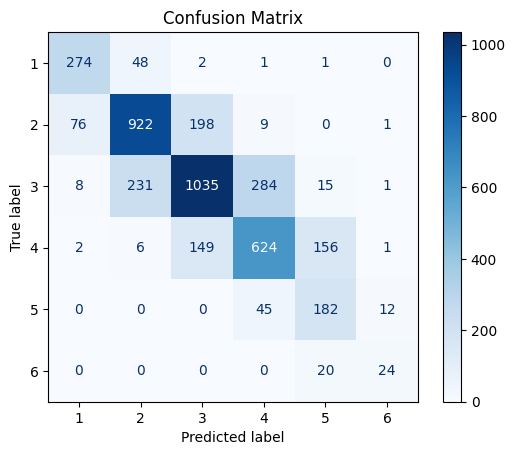

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate and display the confusion matrix for the test predictions
cm = confusion_matrix(y_true, predictions, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [76]:
# Identifying misclassified samples
misclassified_indices = (y_true != predictions)
misclassified_samples = val_features[misclassified_indices]
misclassified_true_labels = y_true[misclassified_indices]
misclassified_predicted_labels = predictions[misclassified_indices]


In [77]:
# Examining features of misclassified samples
import pandas as pd
misclassified_df = pd.DataFrame(misclassified_samples)
misclassified_df['True_Label'] = misclassified_true_labels
misclassified_df['Predicted_Label'] = misclassified_predicted_labels
# Display the first few rows of the misclassified samples
misclassified_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,True_Label,Predicted_Label
0,0.154565,0.789058,0.098066,0.006899,0.001223,0.001459,0.468599,0.468499,0.583609,0.385672,0.411365,0.476265,0.126516,0.000000,0.157367,0.11424,0.057636,0.038240,0.454017,0.059883,0.110714,0.154361,0.000000,0.208768,0.061884,0.0,0.107120,0.000000,0.000000,0.132867,0.036456,0.000000,0.228112,0.000000,0.099963,0.065252,0.0,0.000000,0.000000,0.099623,0.050898,0.410030,0.000000,0.069164,0.051190,0.049301,0.159199,0.000000,0.000000,0.198821,0.222582,0.042734,0.165621,0.190738,0.036947,0.000000,0.000000,0.324995,0.115980,0.185993,0.118969,0.108624,0.000000,0.057790,0.255951,0.071365,0.041503,0.046566,0.000000,0.228817,0.000000,0.206556,0.108794,0.087433,0.158662,0.0,0.000000,0.072379,0.089537,0.0,0.039697,0.053955,0.202870,0.000000,0.122839,0.067763,0.0,0.182547,0.054868,0.230507,0.0,0.0,0.036963,0.075569,0.072486,0.066562,0.178942,0.205667,0.073957,0.036748,0.058289,0.463854,0.000000,0.426962,0.00000,0.357970,0.000000,0.479788,0.032300,0.045746,0.036513,0.085510,0.146245,0.0,0.0,0.039490,0.000000,0.000000,0.0,0.000000,0.000000,0.071365,0.401316,0.232982,0.055004,0.0,0.000000,0.000000,0.0,0.0,0.101516,0.077326,0.058432,0.111134,0.318008,0.000000,0.061423,0.000000,0.083924,0.000000,0.0,0.643874,0.067981,0.235656,0.148815,0.033161,0.000000,0.069248,0.436687,0.26961,0.066993,0.075052,0.197227,0.00000,0.000000,0.000000,0.061964,0.125591,0.000000,0.000000,0.000000,0.000000,0.0,0.161684,0.207837,0.044213,0.054701,0.0,0.045774,0.051206,0.405058,0.045122,0.044711,0.088156,0.0,0.118803,0.044987,0.079500,0.195974,0.000000,0.056987,0.000000,0.124106,0.131413,0.055002,0.000000,0.135019,0.000000,0.058256,0.069080,0.148756,0.114880,0.000000,0.122928,0.192508,0.0,0.296500,0.043631,0.156163,0.296910,0.256567,0.000000,0.000000,0.159920,0.045415,0.128252,0.069007,0.057989,0.412606,0.082838,0.000000,0.049770,0.228571,0.711378,0.551117,0.326117,0.336264,0.710774,0.364280,0.578822,0.379571,0.457979,0.648876,0.285534,0.558463,0.355019,0.654266,0.495664,0.470325,0

In [78]:
# # Feature importance from LightGBM
# feature_importance = best_model.feature_importance(importance_type='gain')
# feature_names = val_features.columns
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# # Sort features by importance
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)


In [79]:
# Checking class distribution in the true labels
label_counts = pd.Series(y_true).value_counts()
print(label_counts)


3    1574
2    1206
4     938
1     326
5     239
6      44
Name: count, dtype: int64


In [80]:
# from sklearn.model_selection import GridSearchCV
# # Define the hyperparameters to tune
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],
#     'num_leaves': [31, 62, 128],
#     'n_estimators': [50, 100, 200]
# }
# grid_search = GridSearchCV(best_model, param_grid, scoring='', cv=5)
# grid_search.fit(val_features, val_labels)
# print("Best parameters:", grid_search.best_params_)


In [81]:
# Check LightGBM version
import lightgbm as lgb
print(lgb.__version__)


4.3.0


In [82]:
# # Ensure the model is fitted
# if not hasattr(best_model, 'feature_importance_'):
#     best_model.fit(val_features, val_labels)  # Train or re-train the model

# # Retrieve feature importance
# feature_importance = best_model.feature_importance_  # Underscore at the end
# feature_names = val_features.columns

# # Create DataFrame for feature importance
# feature_importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importance
# })
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# print(feature_importance_df)


In [87]:
# Assuming `df` is the original DataFrame and `predictions` is a list/array of predicted labels
# If there's a subset used for predictions, ensure it aligns with the DataFrame
val_df['Predicted_Label'] = predictions


In [88]:
print(len(val_features), len(val_df), len(predictions))

4327 4327 4327


In [89]:
val_df.tail()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,misspelling_count,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_

In [90]:
# merge 'clean_text' column back with val df 

text = val_essays[['essay_id', 'clean_text']]

val_df = val_df.merge(text, on = 'essay_id')

val_df.head()

,essay_id,score,deberta_prob_0,deberta_prob_1,deberta_prob_2,deberta_prob_3,deberta_prob_4,deberta_prob_5,xlnet_prob_0,xlnet_prob_1,xlnet_prob_2,xlnet_prob_3,xlnet_prob_4,xlnet_prob_5,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,hash_10,hash_11,hash_12,hash_13,hash_14,hash_15,hash_16,hash_17,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27,hash_28,hash_29,hash_30,hash_31,hash_32,hash_33,hash_34,hash_35,hash_36,hash_37,hash_38,hash_39,hash_40,hash_41,hash_42,hash_43,hash_44,hash_45,hash_46,hash_47,hash_48,hash_49,hash_50,hash_51,hash_52,hash_53,hash_54,hash_55,hash_56,hash_57,hash_58,hash_59,hash_60,hash_61,hash_62,hash_63,hash_64,hash_65,hash_66,hash_67,hash_68,hash_69,hash_70,hash_71,hash_72,hash_73,hash_74,hash_75,hash_76,hash_77,hash_78,hash_79,hash_80,hash_81,hash_82,hash_83,hash_84,hash_85,hash_86,hash_87,hash_88,hash_89,hash_90,hash_91,hash_92,hash_93,hash_94,hash_95,hash_96,hash_97,hash_98,hash_99,hash_100,hash_101,hash_102,hash_103,hash_104,hash_105,hash_106,hash_107,hash_108,hash_109,hash_110,hash_111,hash_112,hash_113,hash_114,hash_115,hash_116,hash_117,hash_118,hash_119,hash_120,hash_121,hash_122,hash_123,hash_124,hash_125,hash_126,hash_127,hash_128,hash_129,hash_130,hash_131,hash_132,hash_133,hash_134,hash_135,hash_136,hash_137,hash_138,hash_139,hash_140,hash_141,hash_142,hash_143,hash_144,hash_145,hash_146,hash_147,hash_148,hash_149,hash_150,hash_151,hash_152,hash_153,hash_154,hash_155,hash_156,hash_157,hash_158,hash_159,hash_160,hash_161,hash_162,hash_163,hash_164,hash_165,hash_166,hash_167,hash_168,hash_169,hash_170,hash_171,hash_172,hash_173,hash_174,hash_175,hash_176,hash_177,hash_178,hash_179,hash_180,hash_181,hash_182,hash_183,hash_184,hash_185,hash_186,hash_187,hash_188,hash_189,hash_190,hash_191,hash_192,hash_193,hash_194,hash_195,hash_196,hash_197,hash_198,hash_199,misspelling_count,dense_vec_0,dense_vec_1,dense_vec_2,dense_vec_3,dense_vec_4,dense_vec_5,dense_vec_6,dense_vec_7,dense_vec_8,dense_vec_9,dense_vec_10,dense_vec_11,dense_vec_12,dense_vec_13,dense_vec_14,dense_vec_15,dense_vec_16,dense_vec_17,dense_vec_18,dense_vec_19,dense_vec_20,dense_vec_21,dense_vec_22,dense_vec_23,dense_vec_24,dense_vec_25,dense_vec_26,dense_vec_27,dense_vec_28,dense_vec_29,dense_vec_30,dense_vec_31,dense_vec_32,dense_vec_33,dense_vec_34,dense_vec_35,dense_vec_36,dense_vec_37,dense_vec_38,dense_vec_39,dense_vec_40,dense_vec_41,dense_vec_42,dense_vec_43,dense_vec_44,dense_vec_45,dense_vec_46,dense_vec_47,dense_vec_48,dense_vec_49,dense_vec_50,dense_vec_51,dense_vec_52,dense_vec_53,dense_vec_54,dense_vec_55,dense_vec_56,dense_vec_57,dense_vec_58,dense_vec_59,dense_vec_60,dense_vec_61,dense_vec_62,dense_vec_63,dense_vec_64,dense_vec_65,dense_vec_66,dense_vec_67,dense_vec_68,dense_vec_69,dense_vec_70,dense_vec_71,dense_vec_72,dense_vec_73,dense_vec_74,dense_vec_75,dense_vec_76,dense_vec_77,dense_vec_78,dense_vec_79,dense_vec_80,dense_vec_81,dense_vec_82,dense_vec_83,dense_vec_84,dense_vec_85,dense_vec_86,dense_vec_87,dense_vec_88,dense_vec_89,dense_vec_90,dense_vec_91,dense_vec_92,dense_vec_93,dense_vec_94,dense_vec_95,dense_vec_96,dense_vec_97,dense_vec_98,dense_vec_99,dense_vec_100,dense_vec_101,dense_vec_102,dense_vec_103,dense_vec_104,dense_vec_105,dense_vec_106,dense_vec_107,dense_vec_108,dense_vec_109,dense_vec_110,dense_vec_111,dense_vec_112,dense_vec_113,dense_vec_114,dense_vec_115,dense_vec_116,dense_vec_117,dense_vec_118,dense_vec_119,dense_vec_120,dense_vec_121,dense_vec_122,dense_vec_123,dense_vec_124,dense_vec_125,dense_vec_126,dense_vec_127,dense_vec_128,dense_vec_129,dense_vec_130,dense_vec_131,dense_vec_132,dense_vec_133,dense_vec_134,dense_vec_135,dense_vec_136,dense_vec_137,dense_vec_138,dense_vec_139,dense_vec_140,dense_vec_141,dense_vec_142,dense_vec_143,dense_vec_144,dense_vec_145,dense_vec_146,dense_vec_147,dense_vec_148,dense_vec_149,dense_vec_150,dense_vec_151,dense_vec_152,dense_vec_153,dense_vec_154,dense_vec_155,dense_vec_156,dense_vec_157,dense_

In [91]:
# Assuming `df` has the original labels in a column named 'True_Label'
misclassified_samples = val_df[val_df['score'] != val_df['Predicted_Label']]

# Display misclassified samples
print(misclassified_samples[['score', 'Predicted_Label', 'clean_text']][:15])


    score  Predicted_Label                                         clean_text
0       3                2  many people have car where they live the thing...
7       2                1  in the text the author uses facts that people ...
8       2                1  the challege of exploring venus is not a great...
10      2                3  limiting car use is a great way clean up green...
15      1                2  the author suggets that studying venus is a wo...
17      2                3  the face that is on mars is just a natural lan...
18      3                4  the use of the facial action coding system in ...
19      4                5  in the challenge of exploring venus the debate...
20      1                2  the face was dicovered on may twenty four two ...
24      4                5  driverless cars are the future google has had ...
27      4                3  in the article the challenge of exploring venu...
28      4                5  fellow citizens there are many reaso

In [92]:
# Example: Analyze original text of misclassified samples
misclassified_text = misclassified_samples['clean_text']  # Assuming 'Text' is the original text data
print(misclassified_text.head())


0     many people have car where they live the thing...
7     in the text the author uses facts that people ...
8     the challege of exploring venus is not a great...
10    limiting car use is a great way clean up green...
15    the author suggets that studying venus is a wo...
Name: clean_text, dtype: object


In [93]:
# load tf model
misclassified_text[0]






'many people have car where they live the thing they do not know is that when you use a car alot of thing can happen like you can get in accidet or the smoke that the car has is bad to breath on if someone is walk but in vauban germany they dont have that proble because seventy percent of vaubans families do not own cars and fifty seven percent sold a car to move there street parkig driveways and home garages are forbidden on the outskirts of freiburd that near the french and swiss borders you probaly will not see a car in vaubans streets because they are completely car free but if some that lives in vauban that owns a car ownership is allowed but there are only two places that you can park a large garages at the edge of the development where a car owner buys a space but it not cheap to buy one they sell the space for you car for forty zero along with a home the vauban people completed this in two thousand and six they said that this an example of a growing trend in europe the untile s